# 2. The spatial scale of interactions

Notebook 01 asked whether two cell types and the genes they express are close *on average*. That collapses geometry
to one number per cell type pair. Here we keep the distance axis and ask at **which
distances** an interaction is enriched.

We use two related statistics to do that:

**Cross-PCF** (cross pair-correlation function) measures whether two cell types occur near
one another more or less frequently than expected at given distances.
<br>

**LRIC** (Ligand–Receptor Interaction Correlation) extends this idea by incorporating
ligand and receptor expression. Rather than counting every neighbouring cell pair equally,
it weights **sender cells by ligand expression** and **receiver cells by receptor
expression**.

<img src="../../figures/LRIC_summary.png" width=1200 />

## Interpreting cross-PCF and LRIC results

Both methods return a distance-dependent statistic, `g(r)`, calculated per distance bin. The
`radius` column is the bin's **inner edge**: with `radius_step=20` the bin reported at
`radius = 40` covers 40–60 µm (the first bin, reported at `radius = 0`, is wider — see below).
<br>

g(r) > 1 indicates enrichment at distance r. <br>
g(r) ≈ 1 indicates no enrichment beyond the null expectation. <br>
g(r) < 1 indicates depletion or spatial avoidance.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import liana as li

In [2]:
adata = sc.read_h5ad("../../data/brain_section.h5ad")
adata

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'cell_type_colors', 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: 'counts', None (.X)

In [3]:
## Set variables
cell_type_key = "cell_type"
spatial_key = "X_spatial_coords"

resource = li.rs.select_resource('mouseconsensus')
print(f"{len(resource)} LR pairs in resource")

3989 LR pairs in resource


## Choose the right parameters
All distance parameters are in the same units as the spatial coordinates — **µm** for this
MERFISH dataset. <br>
**radius_step** = step between bin inner edges (e.g. 20-25 µm, the typical upper bound of
the diameter of generic cells; though this might vary a lot depending on the tissue and
cell types!). <br>
**annulus_steps** = width of each annulus ring, counted in `radius_step`s (so the ring
width is `annulus_steps * radius_step`). <br>
The default `annulus_steps = 1` gives non-overlapping bins that tile the full range
without gaps. Setting `annulus_steps > 1` makes consecutive annuli overlap — a moving
window over the same tiles — which smooths `g(r)` at the cost of correlating neighbouring
bins. <br>
**max_radius** = approximately the inner edge of the last bin (rounded up to a multiple of `radius_step`); the outer edge extends to
`max_radius + annulus_steps * radius_step`.

In [4]:
radius_step = 20

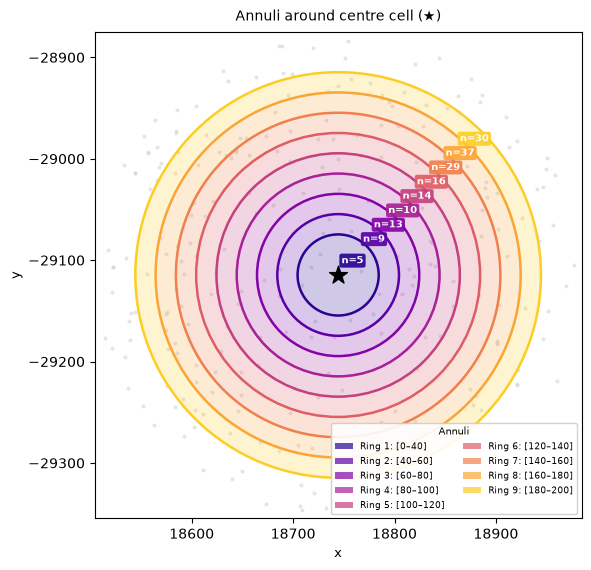

In [5]:
li.pl.annulus(
    adata,
    spatial_key="X_spatial_coords",
    radius_step=radius_step,
    n_rings=9,
    seed=5,
    figure_size= (6, 6),
    return_fig=False)

Note that, by default (`extend_first_annulus=True`), the innermost `[0, radius_step)`
contact band is merged **into the first annulus**, which therefore spans
`[0, (1 + annulus_steps) * radius_step)` and starts at radius 0. Distances are measured
from each **focal cell's centroid**, so cell centroids cannot lie closer than ~one cell
diameter; the innermost band is otherwise a thin, near-empty, high-variance bin. Merging
it folds genuine cell–cell contact pairs into the first bin instead of discarding them.
Set `extend_first_annulus=False` to keep the first ring at
`[radius_step, (1 + annulus_steps) * radius_step)`.

## Ranking interactions using the AUC–log2 score

`g(r)` is a curve per interaction. To compare many interactions, we apply the **AUC-log2
score**: the mean area under `log2 g(r)`.

- **`log2`** puts enrichment and depletion on one symmetric axis: `0` = null,
  `+1` = 2× enriched, `−1` = 2× depleted.
- **Integrate over radius.** The score is the area under `log2 g(r)`,

$$\text{score} = \frac{1}{\Delta r}\int \log_2 g(r)\,dr$$

Integrating (rather than taking the peak) makes the score reflect the *whole* curve: a
pair that is consistently enriched across radii accumulates a large area, while a single
noisy bin contributes only a thin sliver. Dividing by the radial span `Δr` turns the area
into a **mean log2 fold-change**. By default (`max_dist=None`) the integral runs over all
radii; below we pass `max_dist=50` to restrict it to a **short-range window**.

`li.mt.get_lric_auc` returns one row per interaction with the same id columns as the
result it summarises (`source`/`target`/`ligand_complex`/`receptor_complex`/`interaction`)
plus `score`, sorted most-enriched first — so it drops straight into `li.pl.dotplot`.

**Read it as:** `> 0` co-enriched, `< 0` depleted, `≈ 0` random. The magnitude is a
fold-change (`2**score`, so `1` ≈ 2×).

## Cross-PCF

Cross-PCF answers a **purely spatial** question:

> Are cells of type B more (or less) frequent around cells of type A at distance r than expected if cell-type labels were randomly shuffled across the same observed cell locations?

It treats all cells **equally**. Gene expression is not considered. We use it to
characterise the raw spatial architecture of the tissue before asking about LR
interactions.

With `min_cells=None`, both `cross_pcf` and `lric` drop cell types with ≤1% of cells, because `g(r)` estimated from a few hundred cells is noisy. That removes smooth muscle
cells, neuroblasts, macrophages, tanycytes, lymphocytes, dendritic cells and the rare neuron
types — so pairs involving them from notebooks 01 and 03 do not appear here.

In [6]:
li.mt.cross_pcf(
    adata,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    min_cells= None,
    key_added="cross_pcf", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 51539 cells (min_cells=516).
Using `.X`!
Computing cross-PCF over 11 retained cell types (55 pairs emitted).


In [7]:
## Explore the output: one row per cell-type pair x radius bin
adata.uns["cross_pcf"].head()

,source,target,interaction,radius,g
0,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,0.0,0.861141
1,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,40.0,0.905863
2,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,60.0,0.934052
3,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,80.0,0.979085
4,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,100.0,0.994321


### Aggregation: cells cluster together at a short distance

**Choroid plexus epithelial cells** and **ependymal cells** show strong spatial enrichment,
consistent with their anatomical continuity along the ventricular surface. Choroid plexus
epithelium is a specialised ventricular epithelium that meets the ependymal lining at
choroid plexus attachment and transition zones.

In [8]:
# rank short-range interactions (max_dist=50 µm) by area under log2 g(r) curve
cross_pcf_res = li.mt.get_lric_auc(adata, "cross_pcf", max_dist=50, min_bins=2)
print(cross_pcf_res.head(3).to_string(index=False))

                        source                       target                                                 interaction    score  peak_radius
choroid plexus epithelial cell               ependymal cell               choroid plexus epithelial cell^ependymal cell 3.752287         40.0
choroid plexus epithelial cell vascular leptomeningeal cell choroid plexus epithelial cell^vascular leptomeningeal cell 2.576310         40.0
choroid plexus epithelial cell                     pericyte                     choroid plexus epithelial cell^pericyte 1.306699         40.0


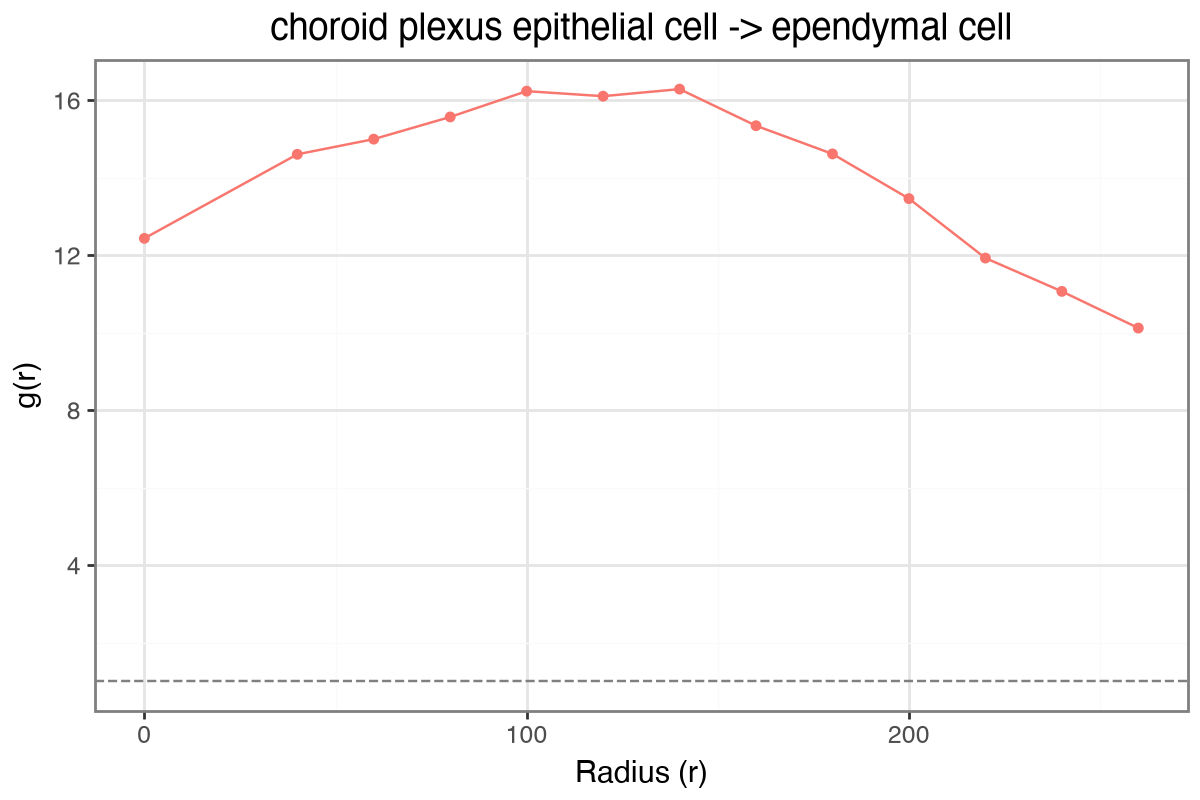

In [9]:
li.pl.lric_lineplot(adata, "cross_pcf",
                    source="choroid plexus epithelial cell",
                    target="ependymal cell")

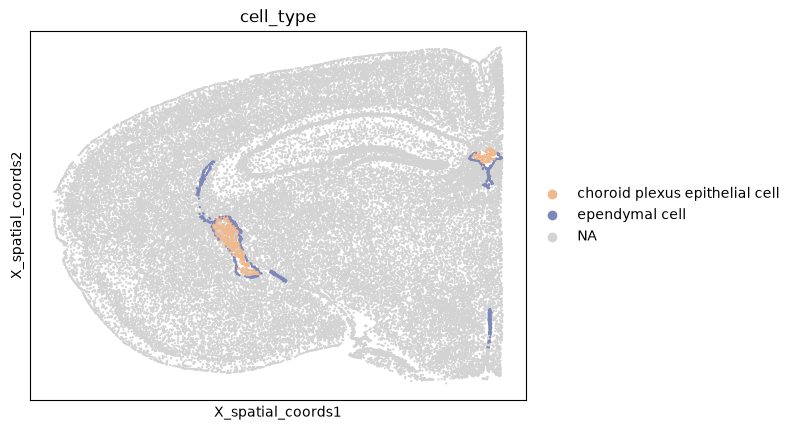

In [10]:
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=cell_type_key,
    groups=["choroid plexus epithelial cell", "ependymal cell"],
    s=10,
)

### Exclusion: cells occupy distinct anatomical compartments

**Choroid plexus epithelial cells** are confined to the choroid plexus at the ventricular
interface, whereas **glutamatergic neurons** are distributed throughout the surrounding
brain parenchyma. Their strong depletion, with `g(r)<1`, indicates fewer cross-type
neighbours than expected and primarily reflects spatial compartmentalisation rather than
direct cellular repulsion.

In [11]:
print(cross_pcf_res.tail(3).to_string(index=False))

                        source                         target                                                   interaction     score  peak_radius
choroid plexus epithelial cell           glutamatergic neuron           choroid plexus epithelial cell^glutamatergic neuron -3.116759          0.0
choroid plexus epithelial cell                oligodendrocyte                choroid plexus epithelial cell^oligodendrocyte -3.207982          0.0
choroid plexus epithelial cell oligodendrocyte precursor cell choroid plexus epithelial cell^oligodendrocyte precursor cell -3.836286          0.0


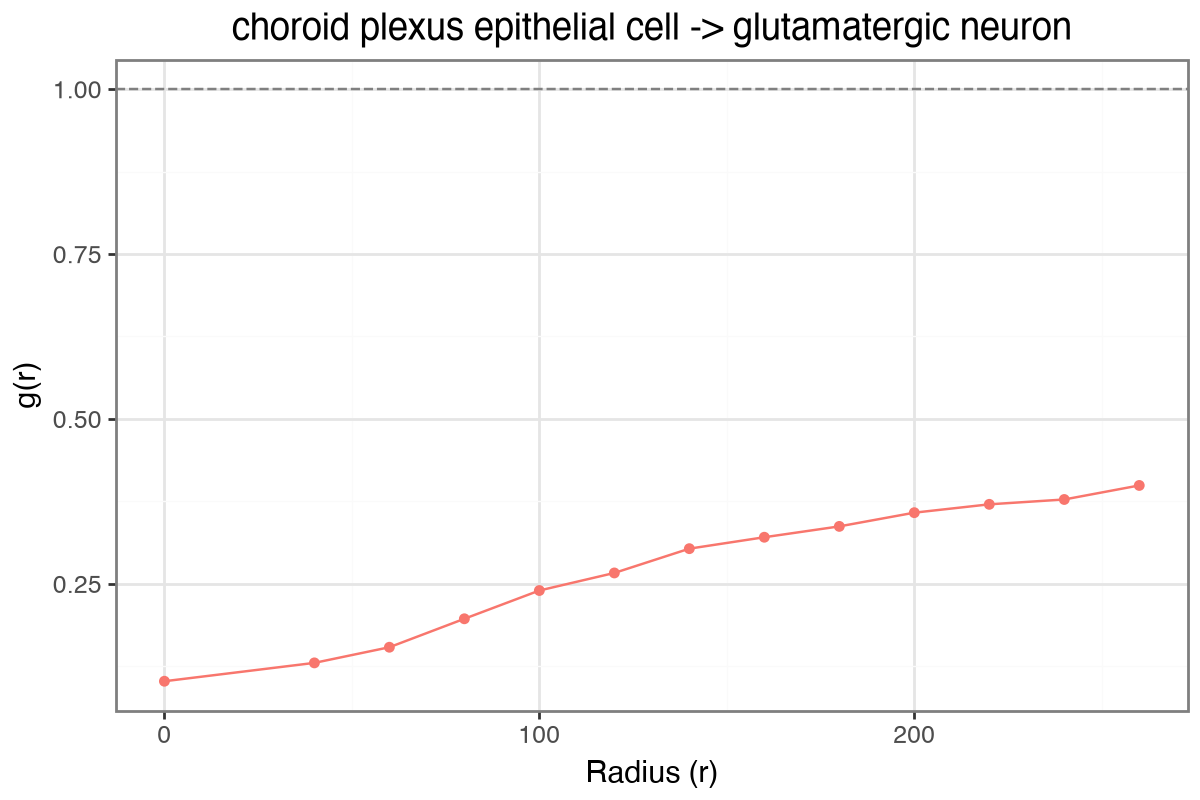

In [12]:
li.pl.lric_lineplot(adata, "cross_pcf",
                    source="choroid plexus epithelial cell",
                    target="glutamatergic neuron")

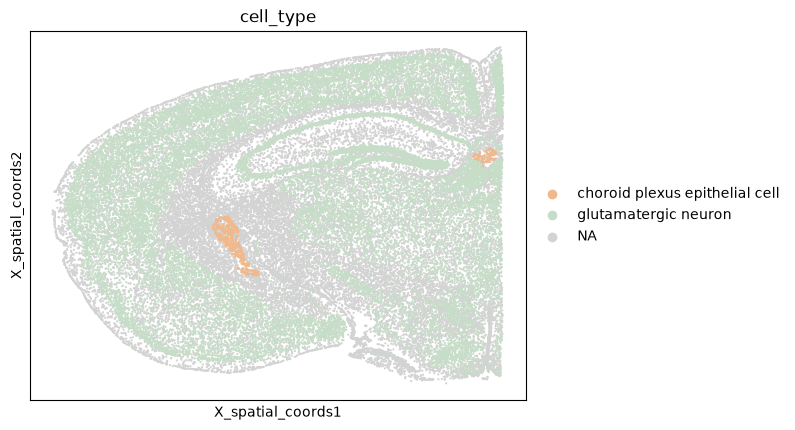

In [13]:
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=cell_type_key,
    groups=["choroid plexus epithelial cell", "glutamatergic neuron"],
    s=10,
)

## LRIC: cell-type informed, directed interactions

The **cell-type-informed** mode splits cells into sender and receiver populations by
cell-type annotation and computes g(r) for every directed **(sender → receiver)** pair,
weighted by LR expression.

This answers a more specific question:

> For the specific interaction **sender cell type X expressing ligand L** → **receiver cell type Y expressing receptor R**, is the LR-weighted spatial co-enrichment at distance r higher than expected?

**Key advantage over cross-PCF**: g(r) combines where the cells sit with how much they
express the ligand/receptor, and the two parts (`g_pcf`, `g_expr`) can be inspected separately.

In [14]:
li.mt.lric(
    adata,
    resource=resource,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    expr_prop=0.2,  # NaN-mask sender/receiver-celltype pairs expressed in <20% of that celltype
    use_raw=False,
    key_added="lric_ct", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 51539 cells (min_cells=516).
Using `.X`!


Using provided `resource`.


0.85 of entities in the resource are missing from the data.
Running LRIC (conditional within-type null) over 11 retained cell types (110 directed pairs emitted).
LRIC: 100%|██████████| 110/110 [00:00<00:00, 140.03it/s]


In [15]:
# short-range interactions (max_dist=50 µm) by area under log2 g(r) curve
lric_ct_res = li.mt.get_lric_auc(adata, "lric_ct", max_dist=50, min_bins=2)
print(lric_ct_res.head(3).to_string(index=False))

                        source                         target ligand_complex receptor_complex  interaction    score  peak_radius
  vascular leptomeningeal cell choroid plexus epithelial cell        Col18a1             Gpc4 Col18a1^Gpc4 4.047474         40.0
choroid plexus epithelial cell                 ependymal cell        Col18a1             Gpc4 Col18a1^Gpc4 3.739544         40.0
choroid plexus epithelial cell                 ependymal cell        Sostdc1             Lrp4 Sostdc1^Lrp4 3.730627         40.0


The AUC ranking uses liana's own column names, so it feeds straight into
`li.pl.dotplot`. Colour shows the signed AUC-log2 score
(enriched > 0, depleted < 0) and dot size its absolute value — how far the interaction
deviates from the null in either direction. (`peak_radius` is not useful for sizing here:
within a 50 µm window it can only be 0 or 40.)

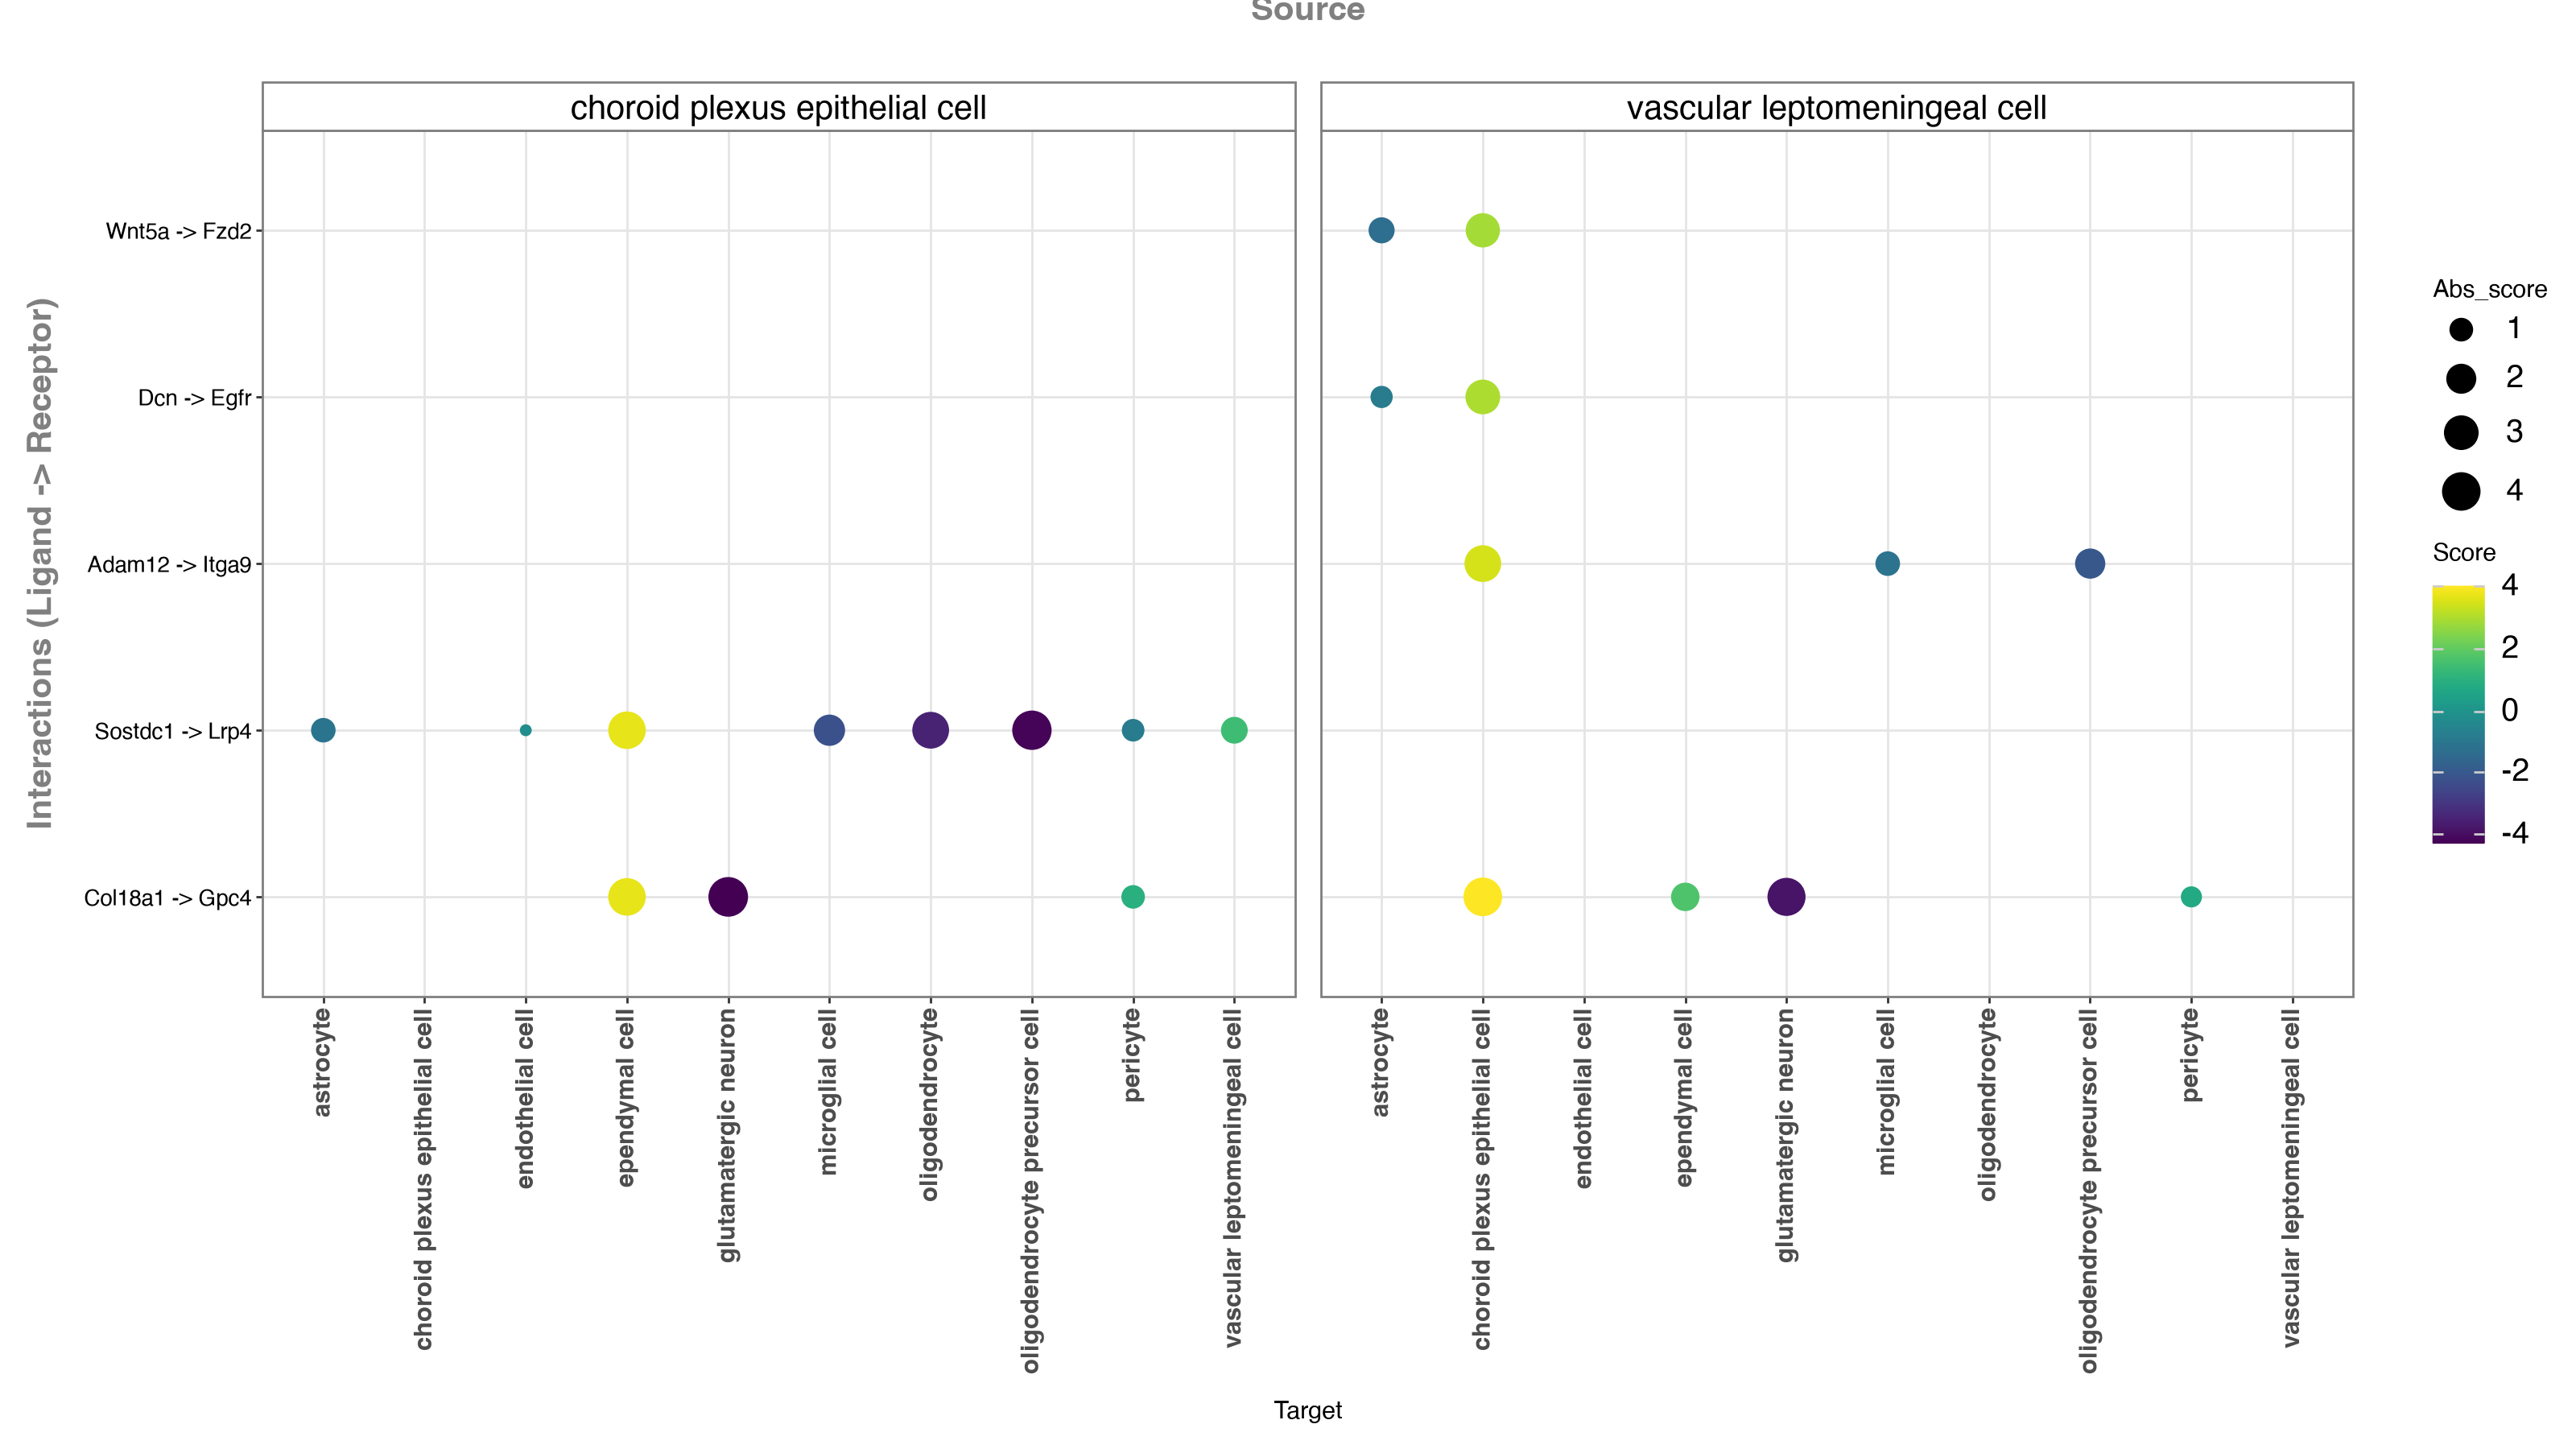

In [16]:
lric_ct_res["abs_score"] = lric_ct_res["score"].abs()

li.pl.dotplot(
    liana_res=lric_ct_res,
    colour="score", size="abs_score",
    orderby="score",
    orderby_ascending=False, top_n=5,
    figure_size=(16, 9),
    source_labels=['vascular leptomeningeal cell', 'choroid plexus epithelial cell']
)

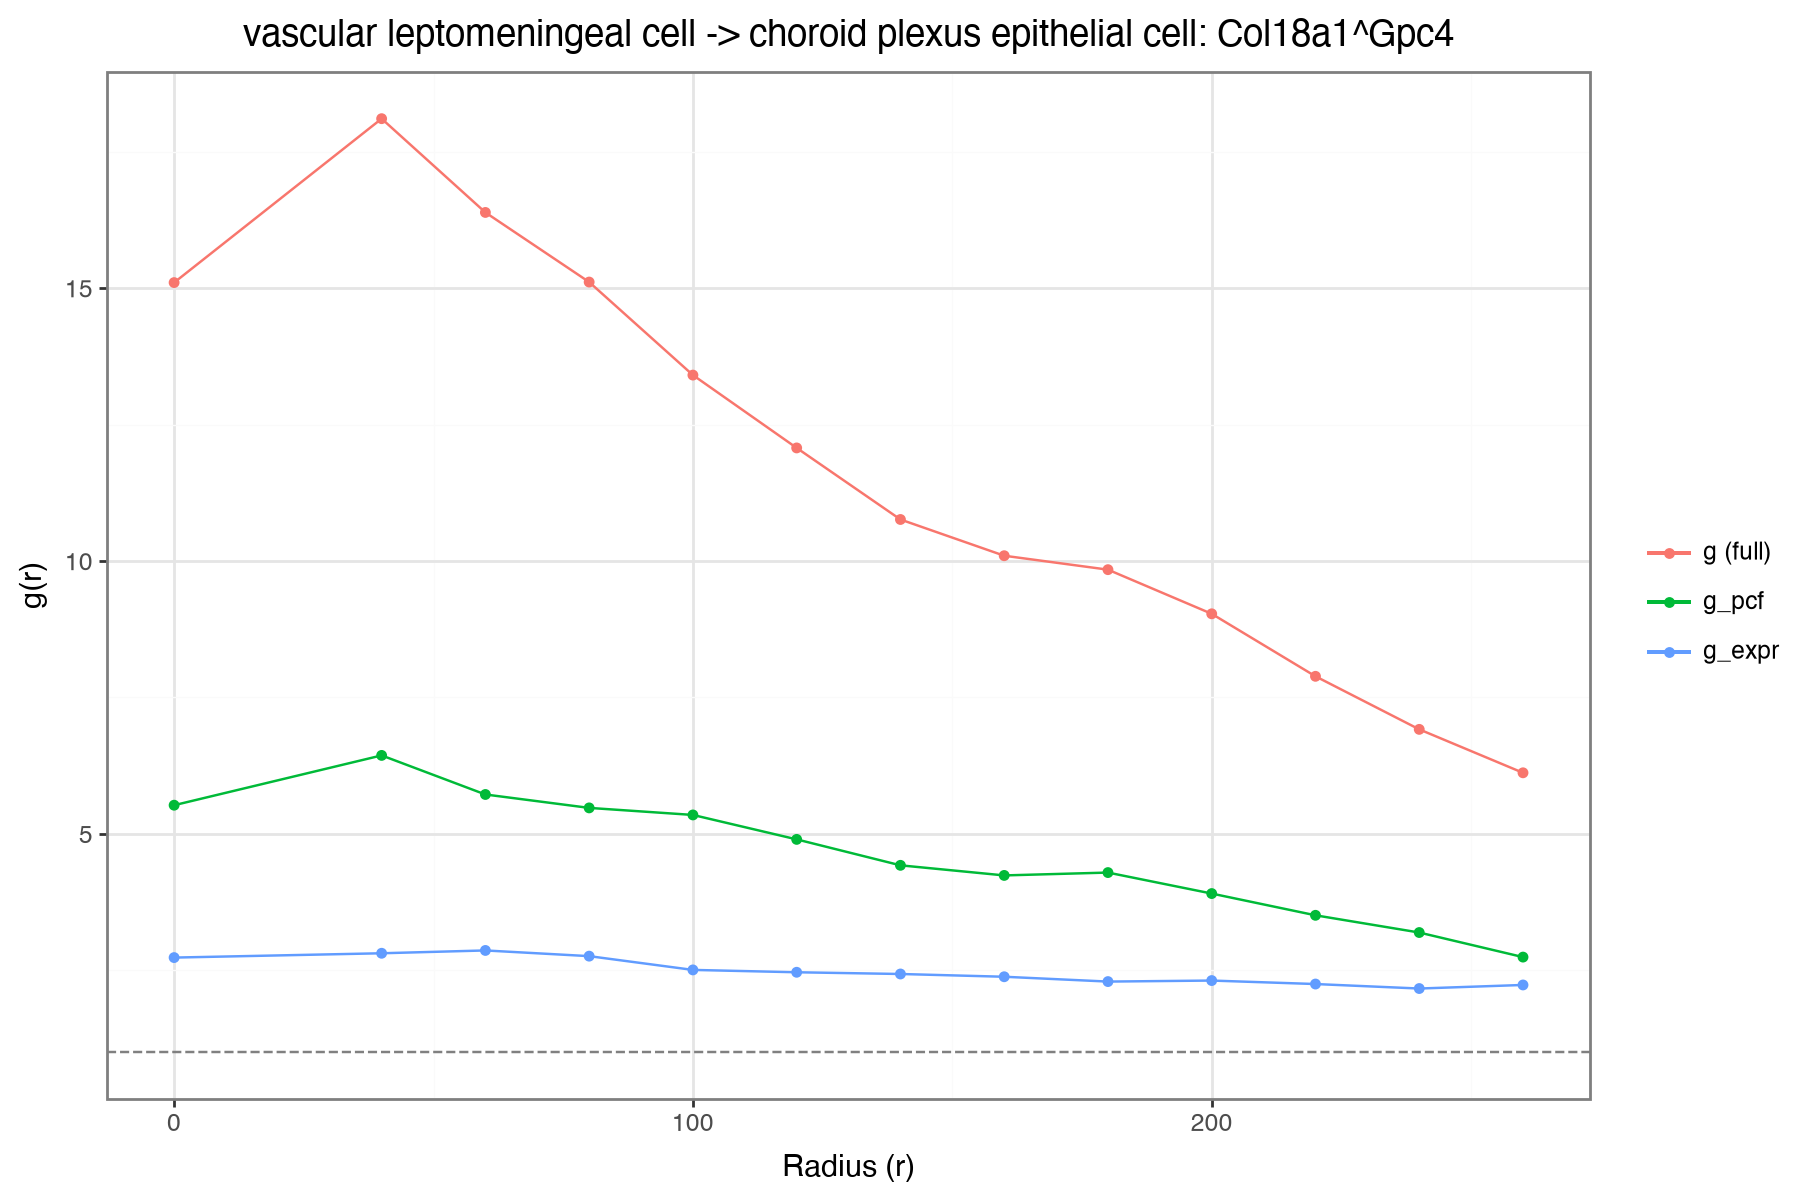

In [17]:
li.pl.lric_lineplot(adata, 
                    uns_key="lric_ct",
                    source="vascular leptomeningeal cell",
                    target="choroid plexus epithelial cell",
                    interaction="Col18a1^Gpc4",
                    figure_size=(9,6))

**Col18a1 $\rightarrow$ Gpc4** from **vascular leptomeningeal cells $\rightarrow$ choroid
plexus epithelial cells** shows the strongest cell-type-informed spatial enrichment, with
$g_{\mathrm{full}}(r)$ peaking at approximately **18 in the 40–60 µm bin**.

The underlying cell-type organisation is already strongly enriched
($g_{\mathrm{pcf}} \approx 6.4$ there), reflecting the close spatial association of vascular
leptomeningeal and choroid plexus epithelial cells. Ligand–receptor expression adds a further
factor ($g_{\mathrm{expr}} \approx 2.8$), so $g_{\mathrm{full}} \approx g_{\mathrm{pcf}} \times g_{\mathrm{expr}}$.

Note, however, that $g_{\mathrm{expr}}$ is nearly flat (≈2.2–2.9) all the way out to 260 µm.
The Col18a1-high and Gpc4-high subsets are concentrated towards each other at *every* distance,
which points to regional or subpopulation structure (e.g. the parts of the choroid plexus
where both are high) rather than a contact-range effect. Distance-dependence would show up as
$g_{\mathrm{expr}}$ falling towards 1 with radius.

---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 1 — Does the scale depend on the binning?**

`radius_step` sets how finely distance is binned, and `max_radius` how far out we look.
Both are choices, not measurements.

Re-run `li.mt.cross_pcf` with `radius_step=10` and `radius_step=40` (keep `max_radius=250`),
then compare the `score` and `peak_radius` reported by `li.mt.get_lric_auc(..., max_dist=100, min_bins=2)`
for the choroid plexus epithelial → ependymal pair.

Does the detected scale survive a change of binning?
</div>

In [18]:
for step in [10, 20, 40]:
    li.mt.cross_pcf(adata, groupby=cell_type_key, spatial_key=spatial_key,
                    max_radius=250, radius_step=step, min_cells=None,
                    key_added=f"pcf_{step}", verbose=False)
    # ... score with get_lric_auc(max_dist=100, min_bins=2) and pull out the choroid plexus -> ependymal row
    print(step)

10
20
40


<details>
<summary><b>Solution</b></summary>

```python
for step in [10, 20, 40]:
    li.mt.cross_pcf(adata, groupby=cell_type_key, spatial_key=spatial_key,
                    max_radius=250, radius_step=step, min_cells=None,
                    key_added=f"pcf_{step}", verbose=False)
    res = li.mt.get_lric_auc(adata, f"pcf_{step}", max_dist=100, min_bins=2)
    row = res[(res["source"] == "choroid plexus epithelial cell") &
              (res["target"] == "ependymal cell")]
    print(f"radius_step={step:>3} µm | score={row['score'].iloc[0]:.3f} "
          f"| peak_radius={row['peak_radius'].iloc[0]}")
```

The *qualitative* answer is stable — this pair is strongly enriched at every binning
(score ≈ 3.8–3.9). The *numbers* are not: `peak_radius` can only ever
be a bin edge (90, 80, 80 µm here), and it now sits at the edge of the 100 µm window — the
enrichment does not decay within it, so "the scale" of this pair is set by the window as much
as by the biology.

The binning also changes the first bin. With the default `extend_first_annulus=True` the first
bin spans `[0, 2 × radius_step)`: 0–20 µm at `radius_step=10` but 0–80 µm at `radius_step=40`.
With the `max_dist=50` used above, `radius_step=40` would leave a single bin in the window, and
`min_bins=2` would drop every interaction (hence `max_dist=100` here).

The practical lesson: report the binning and the window alongside any claim about "the scale"
of an interaction.

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 2 — Follow your own interaction**

Pick a different interaction from `lric_ct_res` and plot its curve with `li.pl.lric_lineplot`.

Is it enriched (g > 1) or depleted (g < 1)? Over what range of distances? And does the
`g_expr` component tell you the expression is adding anything, or is the signal purely
cell-type architecture?
</div>

In [19]:
# your turn
lric_ct_res.head(20)

# li.pl.lric_lineplot(adata, uns_key="lric_ct", source=..., target=..., interaction=...)


,source,target,ligand_complex,receptor_complex,interaction,score,peak_radius,abs_score
0,vascular leptomeningeal cell,choroid plexus epithelial cell,Col18a1,Gpc4,Col18a1^Gpc4,4.047474,40.0,4.047474
1,choroid plexus epithelial cell,ependymal cell,Col18a1,Gpc4,Col18a1^Gpc4,3.739544,40.0,3.739544
2,choroid plexus epithelial cell,ependymal cell,Sostdc1,Lrp4,Sostdc1^Lrp4,3.730627,40.0,3.730627
3,vascular leptomeningeal cell,choroid plexus epithelial cell,Adam12,Itga9,Adam12^Itga9,3.517706,0.0,3.517706
4,ependymal cell,choroid plexus epithelial cell,Fgf1,Egfr,Fgf1^Egfr,3.365211,40.0,3.365211
5,vascular leptomeningeal cell,choroid plexus epithelial cell,Dcn,Egfr,Dcn^Egfr,3.015265,40.0,3.015265
6,vascular leptomeningeal cell,choroid plexus epithelial cell,Wnt5a,Fzd2,Wnt5a^Fzd2,2.905412,40.0,2.905412
7,choroid plexus epithelial cell,vascular leptomeningeal cell,Sfrp1,Fzd2,Sfrp1^Fzd2,2.407939,40.0,2.407939
8,vascular leptomeningeal cell,ependymal cell,Col18a1,Gpc4,Col18a1^Gpc4,1.715368,40.0,1.715368
9,choroid plexus epithelial cell,vascular leptomeningeal cell,Sostdc1,Lrp4,Sostdc1^Lrp4,1.432293,40.0,1.432293


<details>
<summary><b>Solution</b></summary>

Any row works; the interesting comparison is between the components the line plot shows.

`g_full ≈ g_pcf × g_expr`. When `g_expr ≈ 1`, the interaction is enriched only because the
two cell types sit next to each other — LRIC is telling you nothing that cross-PCF did not
already say. When `g_expr` is clearly above 1 (as for `Col18a1^Gpc4`, ≈ 2.8), the ligand-
and receptor-expressing subsets are *additionally* concentrated towards each other beyond
what cell-type architecture explains. Check whether it also changes with distance: a
`g_expr` that stays flat out to the largest radius (as it does for `Col18a1^Gpc4`) reflects
regional or subpopulation structure, not a short-range effect; one that decays towards 1 is
the better candidate for local signalling.

Also note what is missing: `lric` emits no self-pairs, so an interaction within a single
cell type will not appear in this table at all.

</details>

---

**Next:** notebook 03 drops the summary statistics entirely and asks where in the tissue,
cell by cell, an interaction is happening.